<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/skin_cancer9_classesisic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

In [22]:
dataset_path = "/content/drive/MyDrive/Skin cancer ISIC The International Skin Imaging Collaboration"

train_path = os.path.join(dataset_path, "Train")
test_path = os.path.join(dataset_path, "Test")

In [24]:
IMG_SIZE = (300, 300)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [25]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2239 images belonging to 9 classes.
Found 118 images belonging to 9 classes.


In [26]:
NUM_CLASSES = train_generator.num_classes
print("Classes:", NUM_CLASSES)

class_names = list(train_generator.class_indices.keys())
print(class_names)

Classes: 9
['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


In [27]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(2.182261208576998), 1: np.float64(0.6616430260047281), 2: np.float64(2.6187134502923977), 3: np.float64(0.5679857940131913), 4: np.float64(0.6968565203859322), 5: np.float64(0.5384800384800384), 6: np.float64(3.230880230880231), 7: np.float64(1.3744628606507059), 8: np.float64(1.7897681854516387)}


In [28]:
base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(300, 300, 3)
)

base_model.trainable = False

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [29]:
x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(base_model.input, output)

In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_skin_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [32]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint, earlystop, reduce_lr]
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.0970 - loss: 2.3965 
Epoch 1: val_accuracy improved from None to 0.13559, saving model to /content/drive/MyDrive/best_skin_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_skin_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 1549s 11s/step - accuracy: 0.1054 - loss: 2.4092 - val_accuracy: 0.1356 - val_loss: 2.1965 - learning_rate: 5.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1115 - loss: 2.2878
Epoch 2: val_accuracy did not improve from 0.13559
140/140 ━━━━━━━━━━━━━━━━━━━━ 742s 5s/step - accuracy: 0.1152 - loss: 2.3006 - val_accuracy: 0.1186 - val_loss: 2.1952 - learning_rate: 5.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1202 - loss: 2.3198
Epoch 3: val_accuracy did not improve from 0.13559
140/140 ━━━━━━━━━━━━━━━━━━━━ 746s 5s/step - accuracy: 0.1099 - loss: 2.3196 - val_accuracy: 0.1186 - val_loss: 2.2010 - learning_rate: 5.0000e-05
Epoch 4

In [33]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_fine = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[checkpoint, earlystop, reduce_lr]
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1074 - loss: 2.8219
Epoch 1: val_accuracy did not improve from 0.15254
140/140 ━━━━━━━━━━━━━━━━━━━━ 909s 6s/step - accuracy: 0.1188 - loss: 2.6952 - val_accuracy: 0.1356 - val_loss: 2.1663 - learning_rate: 1.0000e-05
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1207 - loss: 2.5829
Epoch 2: val_accuracy did not improve from 0.15254
140/140 ━━━━━━━━━━━━━━━━━━━━ 864s 6s/step - accuracy: 0.1219 - loss: 2.5584 - val_accuracy: 0.1356 - val_loss: 2.1844 - learning_rate: 1.0000e-05
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1113 - loss: 2.5803
Epoch 3: val_accuracy did not improve from 0.15254

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
140/140 ━━━━━━━━━━━━━━━━━━━━ 886s 6s/step - accuracy: 0.1126 - loss: 2.5599 - val_accuracy: 0.1356 - val_loss: 2.1984 - learning_rate: 1.0000e-05
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1304 - loss: 2.

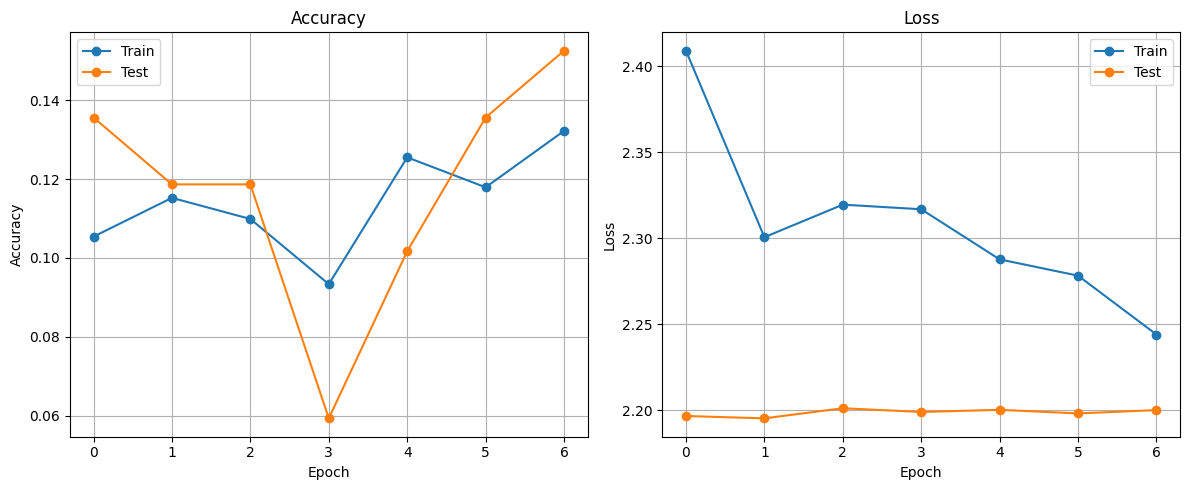

In [34]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(['Train','Test'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(['Train','Test'])

plt.tight_layout()
plt.show()

In [35]:
loss, acc = model.evaluate(test_generator)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {acc*100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step - accuracy: 0.1356 - loss: 2.1663
Test Loss: 2.166314125061035
Test Accuracy: 13.56%


In [36]:
test_generator.reset()

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

8/8 ━━━━━━━━━━━━━━━━━━━━ 48s 5s/step


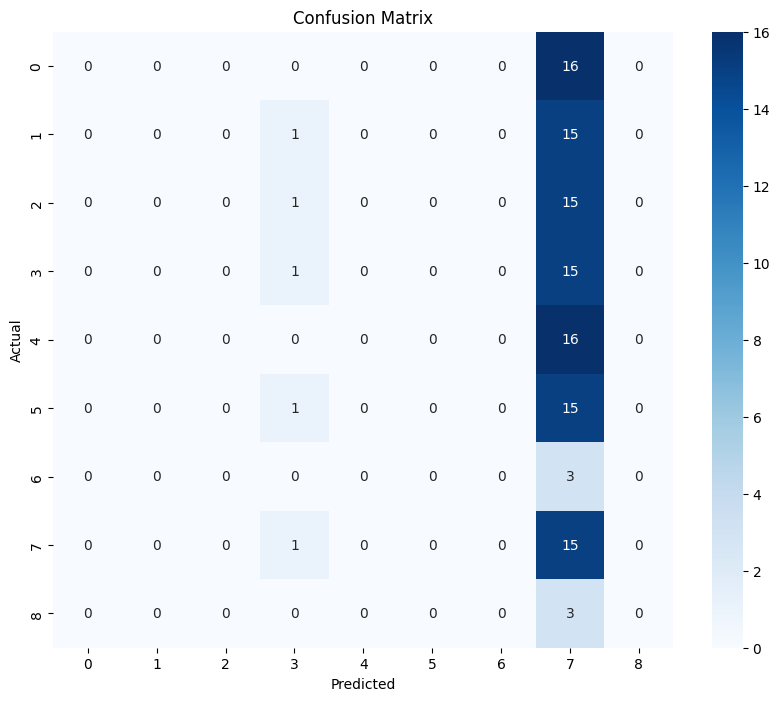

In [37]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [38]:
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
)

print("\nClassification Report\n")
print(report)


Classification Report

                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.00      0.00      0.00        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.20      0.06      0.10        16
                     nevus       0.00      0.00      0.00        16
pigmented benign keratosis       0.00      0.00      0.00        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.13      0.94      0.23        16
           vascular lesion       0.00      0.00      0.00         3

                  accuracy                           0.14       118
                 macro avg       0.04      0.11      0.04       118
              weighted avg       0.05      0.14      0.04       118



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


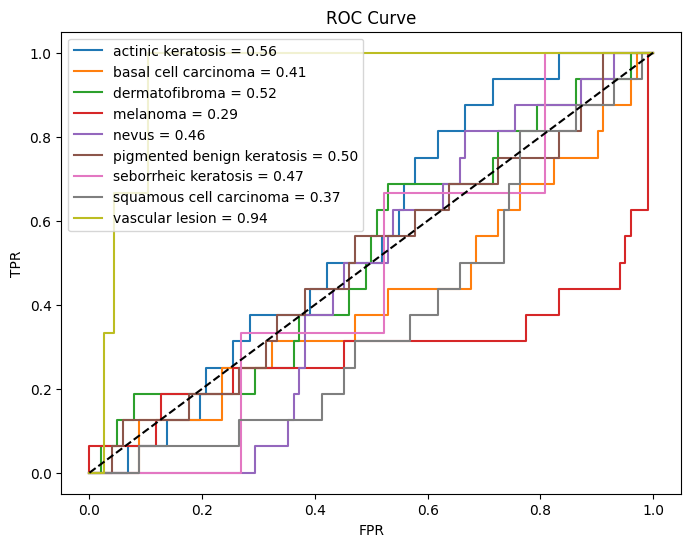

In [40]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# convert labels to binary format (important for multiclass ROC)
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

plt.figure(figsize=(8,6))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{class_names[i]} = {roc_auc:.2f}')

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [41]:
loss, acc = model.evaluate(test_generator)

print("="*40)
print(f"Final Test Accuracy : {acc*100:.2f}%")
print("="*40)

8/8 ━━━━━━━━━━━━━━━━━━━━ 37s 5s/step - accuracy: 0.1356 - loss: 2.1663
Final Test Accuracy : 13.56%
